# Section 1 - Loading Data, Models and Labels

## 1.1 -  Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import random
import torch
import joblib
import json
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 1.2 -  Path Setup

In [3]:
import sys
from pathlib import Path

# Define the Root (at SCANIA COMPONENT X)
PROJECT_ROOT = Path.cwd().parent

# Data Directory (Matches your "Data/Processed Data" folder exactly)
DATA_DIR = PROJECT_ROOT / "Data" / "Processed Data"

# Results Hierarchy
RESULTS_DIR = PROJECT_ROOT / "Results"
MODEL_DIR = RESULTS_DIR / "Models"
PREDICTION_DIR = RESULTS_DIR / "Predictions"

# Adding root to sys.path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Diagnostic Prints
print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")
print(f"Model Path:   {MODEL_DIR}")
print(f"Predictions:  {PREDICTION_DIR}")

# Test if we can see the data file aka. if the path set-up is correct and the file exists
test_file = DATA_DIR / "val_processed.csv"

if test_file.exists():
    print(f"Success! Found {test_file}")
else:
    raise FileNotFoundError(f"Missing expected file: {test_file}")


Project Root: c:\Users\Elias\Documents\SCANIA Component X
Data Source:  c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data
Model Path:   c:\Users\Elias\Documents\SCANIA Component X\Results\Models
Predictions:  c:\Users\Elias\Documents\SCANIA Component X\Results\Predictions
Success! Found c:\Users\Elias\Documents\SCANIA Component X\Data\Processed Data\val_processed.csv


In [4]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Elias\\Documents\\SCANIA Component X\\utils\\__init__.py'>

## 1.3 - Data Loading




In [5]:
# Loading the Test data
test_data = pd.read_csv(DATA_DIR / 'test_processed.csv')

test_data.head()

,vehicle_id,time_step,label,171_0_delta,666_0_delta,427_0_delta,837_0_delta,167_0_delta,167_1_delta,167_2_delta,...,397_26_delta,397_27_delta,397_28_delta,397_29_delta,397_30_delta,397_31_delta,397_32_delta,397_33_delta,397_34_delta,397_35_delta
0,1,4.4,0,-0.849593,-0.749199,-0.885251,-0.605536,0.000000,-0.836776,-0.846642,...,-0.819944,-0.736577,-0.604086,-0.117108,-0.683259,-0.774089,-0.802737,-0.765296,-0.643310,-0.220847
1,1,5.0,0,-0.151501,-0.053569,-0.131260,0.062949,0.076528,-0.121661,-0.188503,...,-0.083977,-0.006910,0.039970,-0.117108,-0.196044,-0.080427,-0.033903,-0.051277,-0.124670,-0.220847
2,1,8.2,0,0.020608,0.188992,0.006265,0.279717,0.903871,-0.046301,-0.068227,...,0.105290,0.161388,0.205490,0.340419,0.100190,0.146219,0.154084,0.176171,0.200403,0.064494
3,1,9.8,0,-0.044545,0.100855,-0.041504,0.273651,0.815721,-0.101013,-0.100659,...,0.032979,0.090441,0.123134,0.451799,0.032254,0.072979,0.091633,0.119040,0.162623,0.203306
4,1,20.6,0,0.085683,0.258760,0.057936,0.425120,0.773686,0.016770,0.002161,...,0.169079,0.227551,0.324457,0.693144,0.249071,0.195101,0.206376,0.241006,0.304681,0.658079


In [6]:
# Loading the saved predictions for the validation set
lr_preds = pd.read_csv(PREDICTION_DIR / 'lr_val_predictions.csv')
lstm_preds = pd.read_csv(PREDICTION_DIR / 'lstm_val_predictions.csv')
tcn_preds = pd.read_csv(PREDICTION_DIR / 'tcn_val_predictions.csv')
smote_lr_preds = pd.read_csv(PREDICTION_DIR / 'smote_lr_val_predictions.csv')
smote_xgb_preds = pd.read_csv(PREDICTION_DIR / 'smote_xgb_val_predictions.csv')

# Loading the true labels for the validation set
val_labels = pd.read_csv(PROJECT_ROOT / "Data" / 'validation_labels.csv')
test_labels = pd.read_csv(PROJECT_ROOT / "Data" / 'test_labels.csv')

# Merging predictions with true labels on 'vehicle_id' to ensure alignment for metric calculations
lr_preds = lr_preds.merge(val_labels, on='vehicle_id')
lstm_preds = lstm_preds.merge(val_labels, on='vehicle_id')
tcn_preds = tcn_preds.merge(val_labels, on='vehicle_id')
smote_lr_preds = smote_lr_preds.merge(val_labels, on='vehicle_id')
smote_xgb_preds = smote_xgb_preds.merge(val_labels, on='vehicle_id')


# Double check the structure of the merged DataFrames to ensure they contain the expected columnsp
print(lr_preds.columns.tolist())
print(lr_preds['class_label'].value_counts().sort_index())


['vehicle_id', 'probability', 'binary_prediction', 'class_label']
class_label
0    4910
1      16
2      14
3      30
4      76
Name: count, dtype: int64


## 1.4 Making the Cost Matrix
The cost Matrix is described [here](https://www.nature.com/articles/s41597-025-04802-6), in this section we define it and set it to a form that we can work with. In this case we are choosing to set it as (actual class , predicted class) as well as its cost. The actual class is derived from the 5-labeled metrics cointained in the raw data, while the predicted class consists of the binary label created in the data preprocessing notebook.



In [15]:
# Cost matrix where keys are (actual_class, predicted_class)
cost_matrix = {
    (0, 0): 0,   (0, 1): 7,
    (1, 0): 200, (1, 1): 0,
    (2, 0): 300, (2, 1): 0,
    (3, 0): 400, (3, 1): 0,
    (4, 0): 500, (4, 1): 0,
}

# Checking that the cost matrix is correctly defined and that the compute_total_cost function works as expected
print(utils.compute_total_cost([4], [0], cost_matrix))  # Should return 500 (false negative)
print(utils.compute_total_cost([0], [1], cost_matrix))  # Should return 7   (false positive)
print(utils.compute_total_cost([0], [0], cost_matrix))  # Should return 0   (true negative)
print(utils.compute_total_cost([1], [1], cost_matrix))  # Should return 0   (true positive)

500
7
0
0


# Section 2 - Standard Metric Evaluation
Here, default threshold = 0.5. 

In [16]:
comparison = pd.DataFrame({
    'LR':        utils.get_metrics(lr_preds),
    'LSTM':      utils.get_metrics(lstm_preds),
    'TCN':       utils.get_metrics(tcn_preds),
    'SMOTE-LR':  utils.get_metrics(smote_lr_preds),
    'SMOTE-XGB': utils.get_metrics(smote_xgb_preds),
})
print(comparison.round(4))

               LR    LSTM     TCN  SMOTE-LR  SMOTE-XGB
Recall     0.8676  0.6103  0.5368    0.8750     0.5441
Precision  0.0353  0.0528  0.0390    0.0362     0.0329
F1         0.0678  0.0972  0.0726    0.0696     0.0621
AUC-ROC    0.6619  0.6877  0.6148    0.6415     0.5809
AUC-PR     0.0494  0.0618  0.0544    0.0406     0.0360


LR — optimal threshold: 0.85, max F1: 0.1048
LSTM — optimal threshold: 0.51, max F1: 0.1014
TCN — optimal threshold: 0.79, max F1: 0.1032
SMOTE-LR — optimal threshold: 0.58, max F1: 0.0765
SMOTE-XGB — optimal threshold: 0.77, max F1: 0.0717


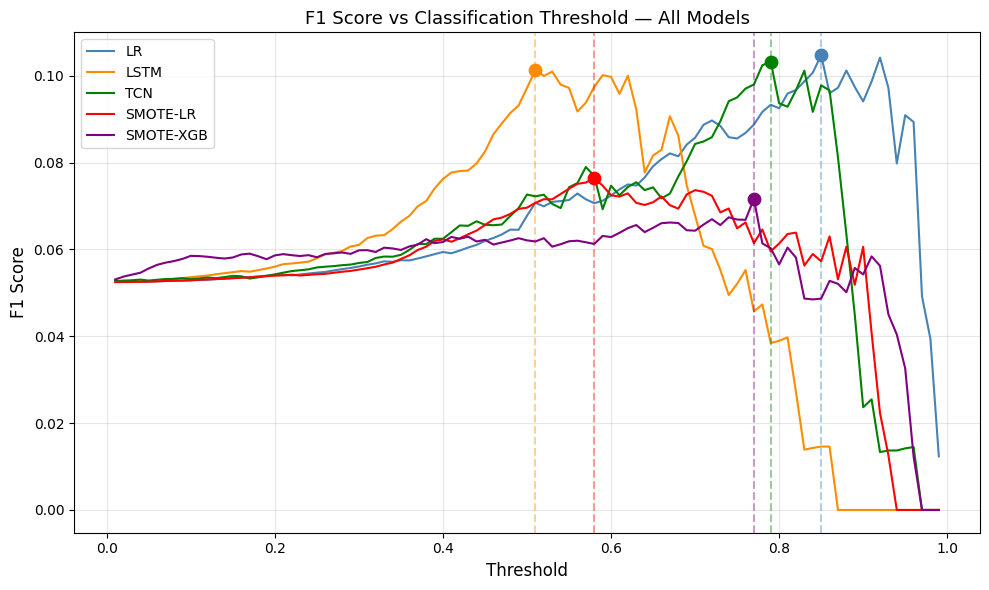

In [17]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 1.0, 0.01)
models = {
    'LR':        lr_preds,
    'LSTM':      lstm_preds,
    'TCN':       tcn_preds,
    'SMOTE-LR':  smote_lr_preds,
    'SMOTE-XGB': smote_xgb_preds,
}

colors = {
    'LR':        'steelblue',
    'LSTM':      'darkorange',
    'TCN':       'green',
    'SMOTE-LR':  'red',
    'SMOTE-XGB': 'purple'
}

f1_by_threshold = {}
for name, df in models.items():
    f1s = []
    for t in thresholds:
        y_true_binary = (df['class_label'].values > 0).astype(int)
        y_pred = (df['probability'].values >= t).astype(int)
        f1s.append(f1_score(y_true_binary, y_pred, zero_division=0))
    f1_by_threshold[name] = f1s

# Find optimal threshold per model
for name, f1s in f1_by_threshold.items():
    best_idx = np.argmax(f1s)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, max F1: {f1s[best_idx]:.4f}")

plt.figure(figsize=(10, 6))
for name, f1s in f1_by_threshold.items():
    best_idx = np.argmax(f1s)
    plt.plot(thresholds, f1s, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name],
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], f1s[best_idx],
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('F1 Score vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

LR — optimal threshold: 0.72, max F2: 0.1761
LSTM — optimal threshold: 0.51, max F2: 0.2019
TCN — optimal threshold: 0.50, max F2: 0.1510
SMOTE-LR — optimal threshold: 0.58, max F2: 0.1668
SMOTE-XGB — optimal threshold: 0.41, max F2: 0.1374


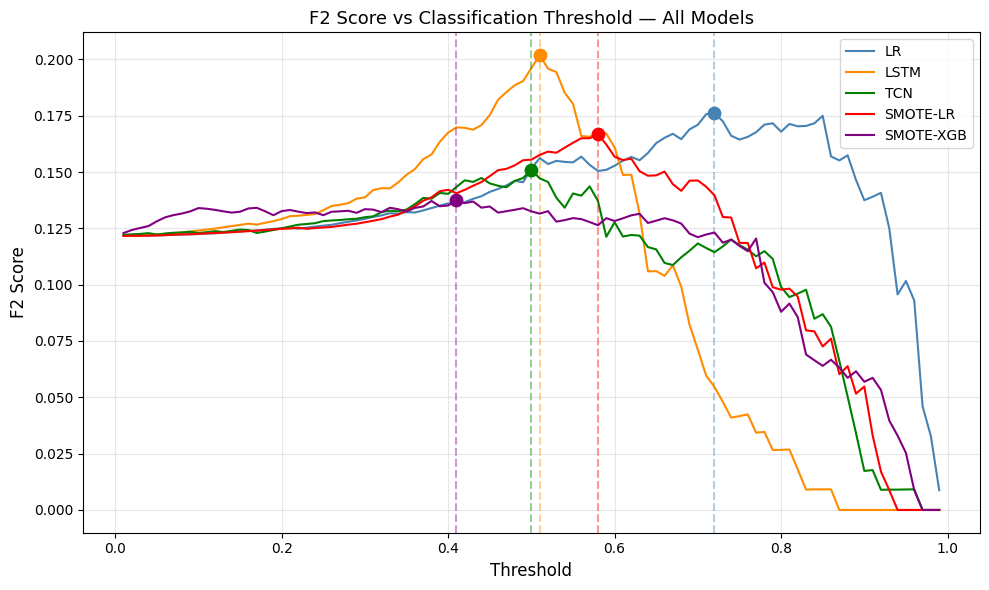

In [18]:
from sklearn.metrics import fbeta_score

fbeta_by_threshold = {}
for name, df in models.items():
    scores = []
    for t in thresholds:
        y_true_binary = (df['class_label'].values > 0).astype(int)
        y_pred = (df['probability'].values >= t).astype(int)
        scores.append(fbeta_score(y_true_binary, y_pred, beta=2, zero_division=0))
    fbeta_by_threshold[name] = scores

for name, scores in fbeta_by_threshold.items():
    best_idx = np.argmax(scores)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, max F2: {scores[best_idx]:.4f}")

plt.figure(figsize=(10, 6))
for name, scores in fbeta_by_threshold.items():
    best_idx = np.argmax(scores)
    plt.plot(thresholds, scores, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name],
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], scores[best_idx],
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F2 Score', fontsize=12)
plt.title('F2 Score vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 3 - Cost-Based Evaluation 

In [19]:
models = {
    'LR':        lr_preds,
    'LSTM':      lstm_preds,
    'TCN':       tcn_preds,
    'SMOTE-LR':  smote_lr_preds,
    'SMOTE-XGB': smote_xgb_preds,
}

costs_at_default = {}
for name, df in models.items():
    y_true = df['class_label'].values
    y_pred = (df['probability'].values >= 0.5).astype(int)
    costs_at_default[name] = utils.compute_total_cost(y_true, y_pred, cost_matrix)

comparison.loc['Cost'] = costs_at_default
print(comparison.round(4))

                   LR        LSTM         TCN    SMOTE-LR   SMOTE-XGB
Recall         0.8676      0.6103      0.5368      0.8750      0.5441
Precision      0.0353      0.0528      0.0390      0.0362      0.0329
F1             0.0678      0.0972      0.0726      0.0696      0.0621
AUC-ROC        0.6619      0.6877      0.6148      0.6415      0.5809
AUC-PR         0.0494      0.0618      0.0544      0.0406      0.0360
Cost       29203.0000  32423.0000  37407.0000  29348.0000  40918.0000


In [12]:
print("LR prob range:", lr_preds['probability'].min(), lr_preds['probability'].max())
print("LSTM prob range:", lstm_preds['probability'].min(), lstm_preds['probability'].max())
print("TCN prob range:", tcn_preds['probability'].min(), tcn_preds['probability'].max())
print("SMOTE-LR prob range:", smote_lr_preds['probability'].min(), smote_lr_preds['probability'].max())
print("SMOTE-XGB prob range:", smote_xgb_preds['probability'].min(), smote_xgb_preds['probability'].max())

# Also check how many positives each model is predicting at 0.5
for name, df in models.items():
    n_pred_positive = (df['probability'] >= 0.5).sum()
    print(f"{name} predicts positive: {n_pred_positive}/{len(df)}")

print("\n False Positives and False Negatives at default threshold:")
for name, df in models.items():
    y_true_binary = (df['class_label'] > 0).astype(int)
    y_pred = (df['probability'] >= 0.5).astype(int)
    false_positives = ((y_pred == 1) & (y_true_binary == 0)).sum()
    false_negatives = ((y_pred == 0) & (y_true_binary == 1)).sum()
    print(f"{name} — FP: {false_positives}, FN: {false_negatives}")

LR prob range: 0.0194635588129466 0.9984347080511504
LSTM prob range: 0.036271058 0.8694718
TCN prob range: 0.0003411649 0.96399796
SMOTE-LR prob range: 0.0160035093837129 0.9708666454696931
SMOTE-XGB prob range: 0.00011444452 0.9978483
LR predicts positive: 3347/5046
LSTM predicts positive: 1572/5046
TCN predicts positive: 1874/5046
SMOTE-LR predicts positive: 3283/5046
SMOTE-XGB predicts positive: 2248/5046

 False Positives and False Negatives at default threshold:
LR — FP: 3229, FN: 18
LSTM — FP: 1489, FN: 53
TCN — FP: 1801, FN: 63
SMOTE-LR — FP: 3164, FN: 17
SMOTE-XGB — FP: 2174, FN: 62


LR — optimal threshold: 0.48, min cost: 28894
LSTM — optimal threshold: 0.40, min cost: 28212
TCN — optimal threshold: 0.42, min cost: 32097
SMOTE-LR — optimal threshold: 0.46, min cost: 28725
SMOTE-XGB — optimal threshold: 0.10, min cost: 31939


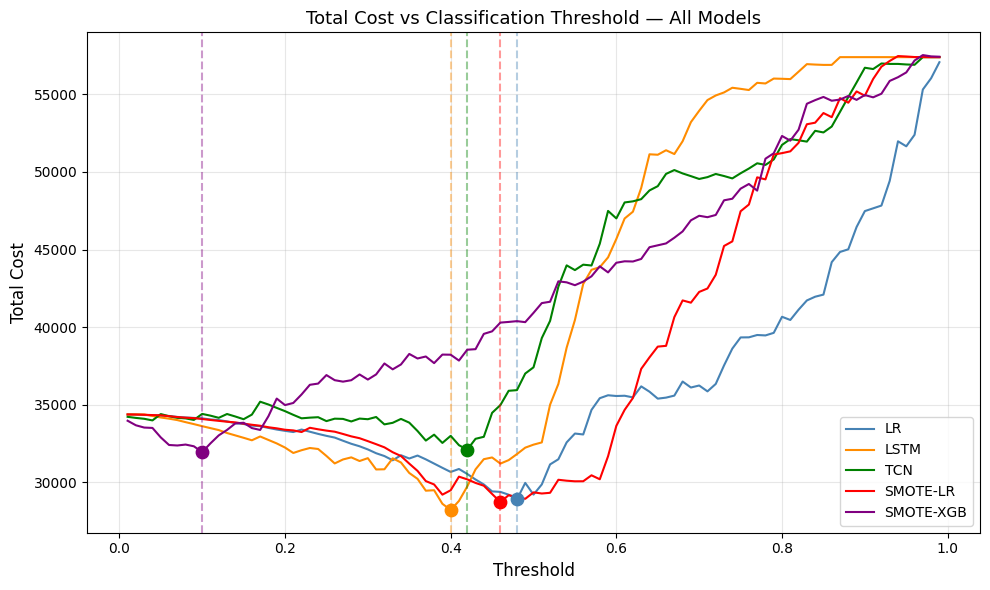

In [20]:
cost_by_threshold = {}
for name, df in models.items():
    costs = []
    for t in thresholds:
        y_true = df['class_label'].values
        y_pred = (df['probability'].values >= t).astype(int)
        costs.append(utils.compute_total_cost(y_true, y_pred, cost_matrix))
    cost_by_threshold[name] = costs

# Find optimal threshold per model
for name, costs in cost_by_threshold.items():
    best_idx = np.argmin(costs)
    print(f"{name} — optimal threshold: {thresholds[best_idx]:.2f}, min cost: {costs[best_idx]:.0f}")


plt.figure(figsize=(10, 6))

colors = {
    'LR': 'steelblue',
    'LSTM': 'darkorange', 
    'TCN': 'green',
    'SMOTE-LR': 'red',
    'SMOTE-XGB': 'purple'
}

for name, costs in cost_by_threshold.items():
    best_idx = np.argmin(costs)
    plt.plot(thresholds, costs, label=name, color=colors[name])
    plt.axvline(x=thresholds[best_idx], color=colors[name], 
                linestyle='--', alpha=0.4)
    plt.scatter(thresholds[best_idx], costs[best_idx], 
                color=colors[name], zorder=5, s=80)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.title('Total Cost vs Classification Threshold — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

SCANIA_COST = {
    (0,0):0,   (0,1):7,   (0,2):8,   (0,3):9,   (0,4):10,
    (1,0):200, (1,1):0,   (1,2):7,   (1,3):8,   (1,4):9,
    (2,0):300, (2,1):200, (2,2):0,   (2,3):7,   (2,4):8,
    (3,0):400, (3,1):300, (3,2):200, (3,3):0,   (3,4):7,
    (4,0):500, (4,1):400, (4,2):300, (4,3):200, (4,4):0,
}

test_data   = pd.read_csv(DATA_DIR / 'test_processed.csv')

# Build test sequences (assuming test_data is loaded — same way as train/val)
X_test_seq, y_test_seq, test_seq_ids = utils.generate_sequential_data(test_data, 'label', SEQ_LEN)

# Get probs from the trained LSTM
_, probs_test = lstm_trainer.predict(X_test_seq)

# Load test labels
test_labels = pd.read_csv(PROJECT_ROOT / 'Data' / 'test_labels.csv')  # adjust filename if different
test_class_labels = test_labels.set_index('vehicle_id').loc[test_seq_ids, 'class_label'].values

# Apply the threshold tuned on val
threshold = 0.45
pred_test = (probs_test >= threshold).astype(int) * 4
cost_test = sum(SCANIA_COST[(int(yt), int(yp))] for yt, yp in zip(test_class_labels, pred_test))

print(f"TEST — threshold (tuned on val): {threshold}")
print(f"TEST — total cost: {cost_test}")
print(f"TEST — cost per vehicle: {cost_test/len(test_class_labels):.2f}")
print(f"TEST — n vehicles: {len(test_class_labels)}")

#### Conclusions

At the default threshold of 0.5, the LR and SMOTE-LR models achieve the lowest 
total cost. However, this is misleading, both models flag approximately 66% of 
all vehicles as failures (3,229 and 3,164 false positives respectively), 
effectively functioning as near-indiscriminate classifiers. While the low cost 
of false positives (7–10) makes this strategy appear cheap in isolation, it is 
operationally unfeasible. Flagging the majority of a fleet for inspection 
eliminates any practical utility of the model, and would be no better than using
standard scheduled maintanance. 

As a result, the threshold sweep across [0.01, 0.99] was performed for all models to find the 
cost-minimizing threshold. Under cost-optimal conditions, LSTM achieves the 
lowest total cost (29,062 at threshold 0.40), while also leading on all standard 
metrics (AUC-PR: 0.062, AUC-ROC: 0.688, F1: 0.097). Notably, this is the only 
model where standard metric ranking and cost-based ranking agree, suggesting 
that LSTM has learned a more discriminative representation of failure patterns 
rather than compensating through aggressive flagging.

For these reasons, LSTM is selected as the best performing model.

**Best Overall Model: LSTM (threshold: 0.40, minimum cost: 29,062)**

# Section 4 - Test Evaluation

## 4.1 - Preparing the Model and the Data

In [14]:
with open(MODEL_DIR / 'hyperparams.json', 'r') as f:
    hp = json.load(f)

lstm_model = utils.LSTMModel(
    input_size=hp['INPUT_SIZE'],
    hidden_size=hp['LSTM']['hidden_size'],
    num_layers=hp['LSTM']['num_layers'],
    dropout=hp['LSTM']['dropout']
)
lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_best.pt', map_location=DEVICE))
lstm_model.to(DEVICE)
lstm_model.eval()

C:\Users\Elias\AppData\Local\Temp\ipykernel_9164\2120460136.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load(MODEL_DIR / 'lstm_best

RuntimeError: Error(s) in loading state_dict for LSTMModel:
	Unexpected key(s) in state_dict: "lstm.weight_ih_l1", "lstm.weight_hh_l1", "lstm.bias_ih_l1", "lstm.bias_hh_l1". 
	size mismatch for lstm.weight_ih_l0: copying a param with shape torch.Size([128, 105]) from checkpoint, the shape in current model is torch.Size([256, 105]).
	size mismatch for lstm.weight_hh_l0: copying a param with shape torch.Size([128, 32]) from checkpoint, the shape in current model is torch.Size([256, 64]).
	size mismatch for lstm.bias_ih_l0: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for lstm.bias_hh_l0: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for fc.weight: copying a param with shape torch.Size([1, 32]) from checkpoint, the shape in current model is torch.Size([1, 64]).

In [ ]:
X_test_seq, y_test_seq = utils.generate_sequential_data(test_data, 'label', hp['SEQ_LEN'])


## 4.2 - Testing the Model 

In [ ]:
with torch.no_grad():
    logits = lstm_model(torch.FloatTensor(X_test_seq).to(DEVICE))
    test_probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    test_preds = (test_probs >= 0.40).astype(int)  # cost-optimal threshold

test_results = pd.DataFrame({
    'vehicle_id': list(test_data.groupby('vehicle_id').groups.keys()),
    'probability': test_probs,
    'prediction': test_preds
})
test_results = test_results.merge(test_labels, on='vehicle_id')

In [ ]:
# Final cost
y_true = test_results['class_label'].values
y_pred = test_results['prediction'].values
final_cost = utils.compute_total_cost(y_true, y_pred, cost_matrix)
print(f"Final Test Cost: {final_cost}")

# Standard metrics
y_true_binary = (y_true > 0).astype(int)
final_metrics = utils.get_metrics(test_results, threshold=0.40)
print(final_metrics)

# FP/FN
fp = ((y_pred == 1) & (y_true_binary == 0)).sum()
fn = ((y_pred == 0) & (y_true_binary == 1)).sum()
print(f"FP: {fp}, FN: {fn}")

Final Test Cost: 32808
{'Recall': 0.7464788732394366, 'Precision': 0.04089506172839506, 'F1': 0.07754206291148501, 'AUC-ROC': 0.6704302913134528, 'AUC-PR': 0.06001761894208256}
FP: 2486, FN: 36


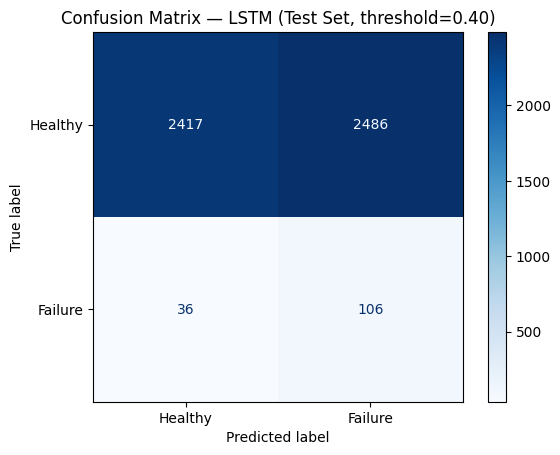

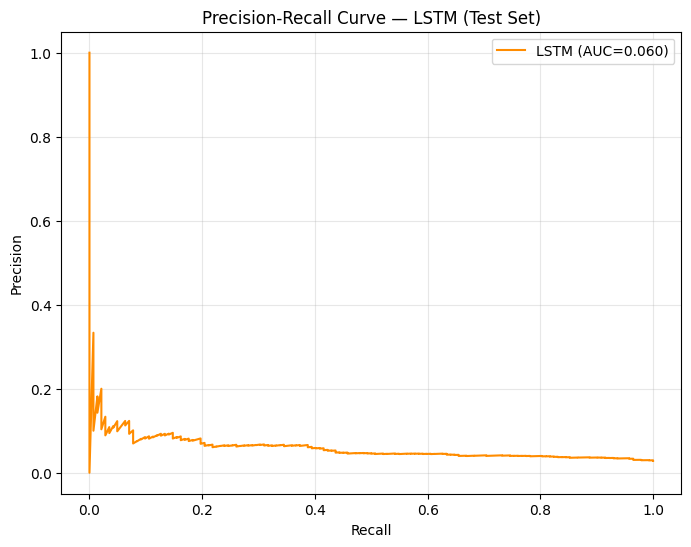

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true_binary, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — LSTM (Test Set, threshold=0.40)')
plt.show()

# PR curve
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_true_binary, test_probs)
auc = average_precision_score(y_true_binary, test_probs)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', label=f'LSTM (AUC={auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — LSTM (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()